# Fraud Detection Bank Project


# Fraud Detection Analysis Using PaySim Dataset

This project aims to analyze fraudulent financial transactions using the PaySim synthetic dataset and compare machine learning models for fraud detection.

## Problem Statement

Financial transaction fraud causes significant losses in banking systems.
This project aims to detect fraudulent transactions using machine learning models and analyze transaction patterns associated with fraud.

#Data Loading

Setup Kaggle API

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Download Dataset dan Extract Dataset

In [ ]:
!kaggle datasets download -d ealaxi/paysim1
!unzip paysim1.zip

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:05<00:00, 35.5MB/s]

Archive:  paysim1.zip
  inflating: PS_20174392719_1491204439457_log.csv  


Import Library

In [ ]:
#data manipulation
import pandas as pd
import numpy as np

#visualization
import seaborn as sns
import matplotlib.pyplot as plt

#preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

#machine learning models
from sklearn.ensemble import RandomForestClassifier

#evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

Load data

In [ ]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

## Dataset Information

The dataset used is PaySim, a synthetic financial transaction dataset that simulates mobile money transactions.

Target variable:
- isFraud

#Data Understanding

Dataset Overview

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Dataset Distribution Analysis

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


Flagged Fraud Distribution

In [ ]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


Missing Value Analysis

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


Dataset Preview

In [ ]:
df.head(20)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [ ]:
#Style Visualization
sns.set_style("whitegrid")

#data shape
print(df.shape)

#data info
df.info()

#preview dataset
print(df.head())

(6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0  

#EDA

Fraud Distribution Analysis

isFraud
0    6354407
1       8213
Name: count, dtype: int64


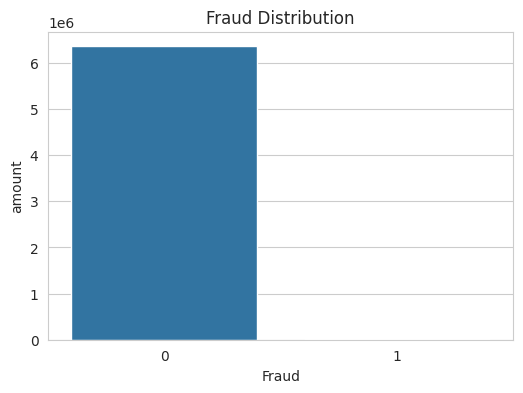

In [ ]:
fraud_count = df['isFraud'].value_counts()

print(fraud_count)

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)

plt.title('Fraud Distribution')
plt.xlabel('Fraud')
plt.ylabel('amount')
plt.show()

### Fraud Distribution Insight

The dataset is highly imbalanced, where fraudulent transactions represent only a very small percentage of total transactions.
This imbalance can affect model performance and evaluation.

Fraud Transaction Type Analysis

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


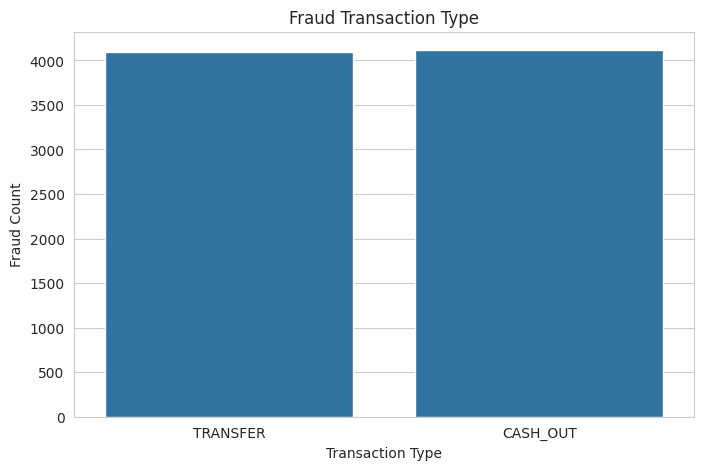

In [ ]:
fraud_by_type = (
    df[df['isFraud'] == 1]['type']
    .value_counts()
)

print(fraud_by_type)

plt.figure(figsize=(8,5))

sns.countplot(
    x='type',
    data=df[df['isFraud'] == 1]
)

plt.title('Fraud Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')

plt.show()

Fraud Percentage by Transaction Type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


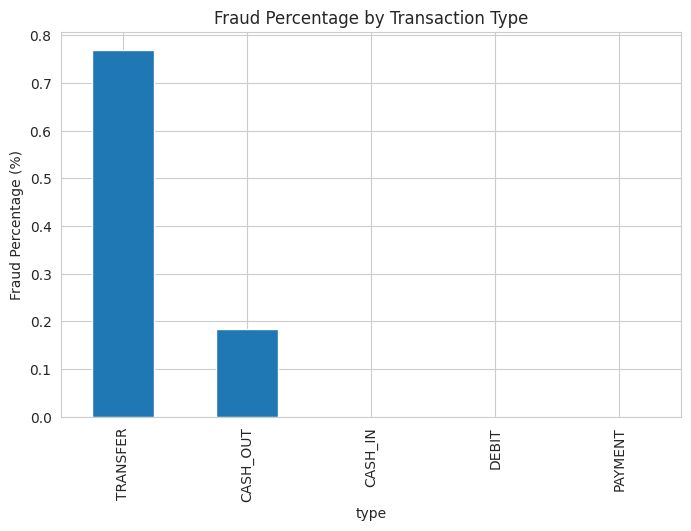

In [ ]:
fraud_percentage = (
    df.groupby('type')['isFraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print(fraud_percentage)

plt.figure(figsize=(8,5))

fraud_percentage.plot(kind='bar')

plt.title('Fraud Percentage by Transaction Type')
plt.ylabel('Fraud Percentage (%)')

plt.show()

### Transaction Type Insight

Fraudulent transactions mainly occur in TRANSFER and CASH_OUT transaction types.
This indicates that these transaction categories are more vulnerable to fraudulent activities.

Transaction Amount Fraud Analysis

In [ ]:
fraud_amount = df[df['isFraud'] == 1]['amount']

print(fraud_amount.describe())

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


Fraud Transaction Amount Distribution

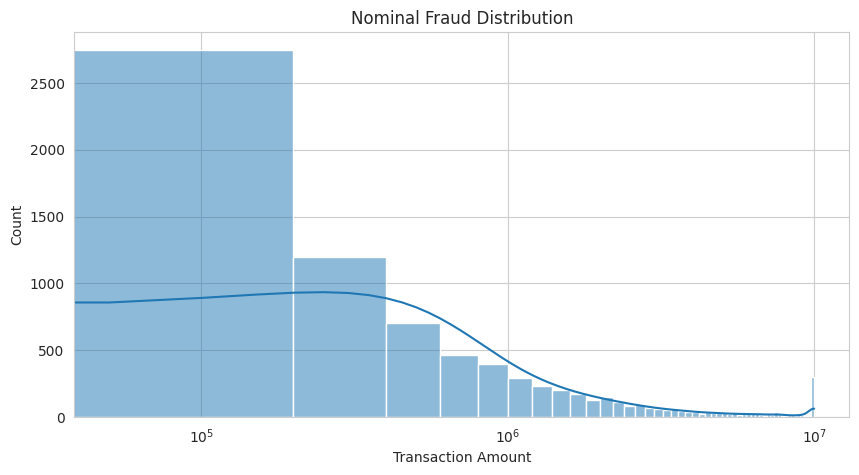

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    fraud_amount,
    bins=50,
    kde=True
)

plt.title('Nominal Fraud Distribution')
plt.xlabel('Transaction Amount')

plt.xscale('log')

plt.show()

### Transaction Amount Insight

Fraudulent transactions tend to involve higher transaction amounts compared to normal transactions.

Fraud vs Non-Fraud Transaction Amount Comparison

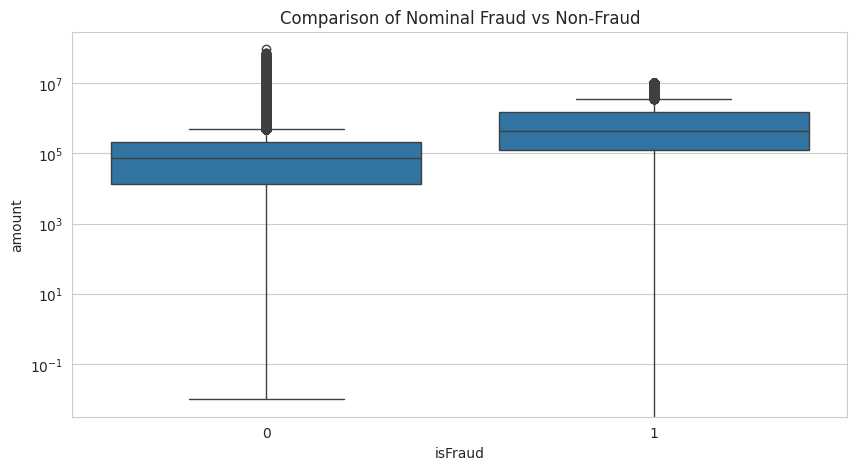

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.yscale('log')

plt.title('Comparison of Nominal Fraud vs Non-Fraud')

plt.show()

Fraud Transaction Time Analysis

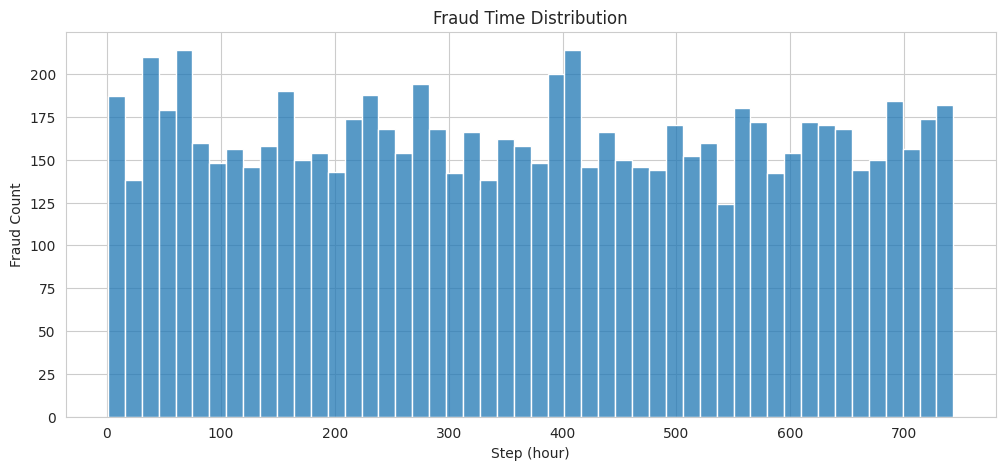

In [ ]:
fraud_time = (
    df[df['isFraud'] == 1]['step']
)

plt.figure(figsize=(12,5))

sns.histplot(
    fraud_time,
    bins=50
)

plt.title('Fraud Time Distribution')
plt.xlabel('Step (hour)')
plt.ylabel('Fraud Count')

plt.show()

Fraud Activity by Hour

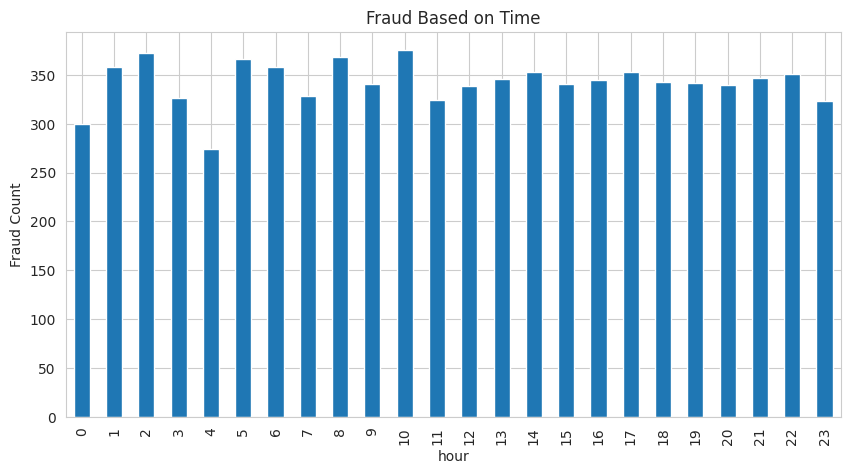

In [ ]:
df['hour'] = df['step'] % 24

fraud_hour = (
    df[df['isFraud'] == 1]
    .groupby('hour')
    .size()
)

plt.figure(figsize=(10,5))

fraud_hour.plot(kind='bar')

plt.title('Fraud Based on Time')
plt.xlabel('hour')
plt.ylabel('Fraud Count')

plt.show()

### Time-Based Fraud Insight

Fraudulent transactions appear at certain transaction steps, indicating possible temporal transaction patterns.

Suspicious Balance Pattern Analysis


In [ ]:
df['balanceDiffOrig'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

df['balanceDiffDest'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)

## Balance Difference Analysis

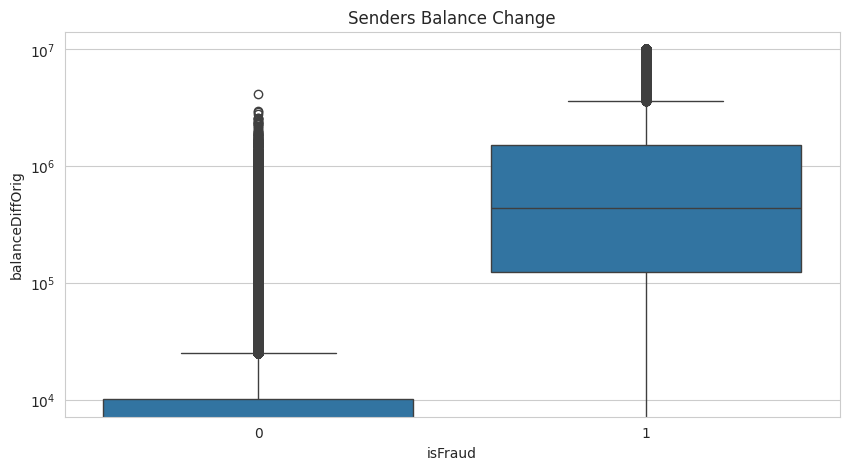

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='isFraud',
    y='balanceDiffOrig',
    data=df
)

plt.yscale('log')

plt.title('Senders Balance Change')

plt.show()

Suspicious Balance Pattern Detection

In [ ]:
weird_balance = df[
    (df['isFraud'] == 1) &
    (df['oldbalanceDest'] == 0) &
    (df['newbalanceDest'] == 0)
]

print(weird_balance.head())

print("Number of strange patterns:", weird_balance.shape[0])

      step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2        1  TRANSFER      181.00  C1305486145         181.00             0.0   
251      1  TRANSFER     2806.00  C1420196421        2806.00             0.0   
680      1  TRANSFER    20128.00   C137533655       20128.00             0.0   
969      1  TRANSFER  1277212.77  C1334405552     1277212.77             0.0   
1115     1  TRANSFER    35063.63  C1364127192       35063.63             0.0   

         nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
2      C553264065             0.0             0.0        1               0   
251    C972765878             0.0             0.0        1               0   
680   C1848415041             0.0             0.0        1               0   
969    C431687661             0.0             0.0        1               0   
1115  C1136419747             0.0             0.0        1               0   

      hour  balanceDiffOrig  balanceDiffDest  
2  

Feature Correlation Analysis

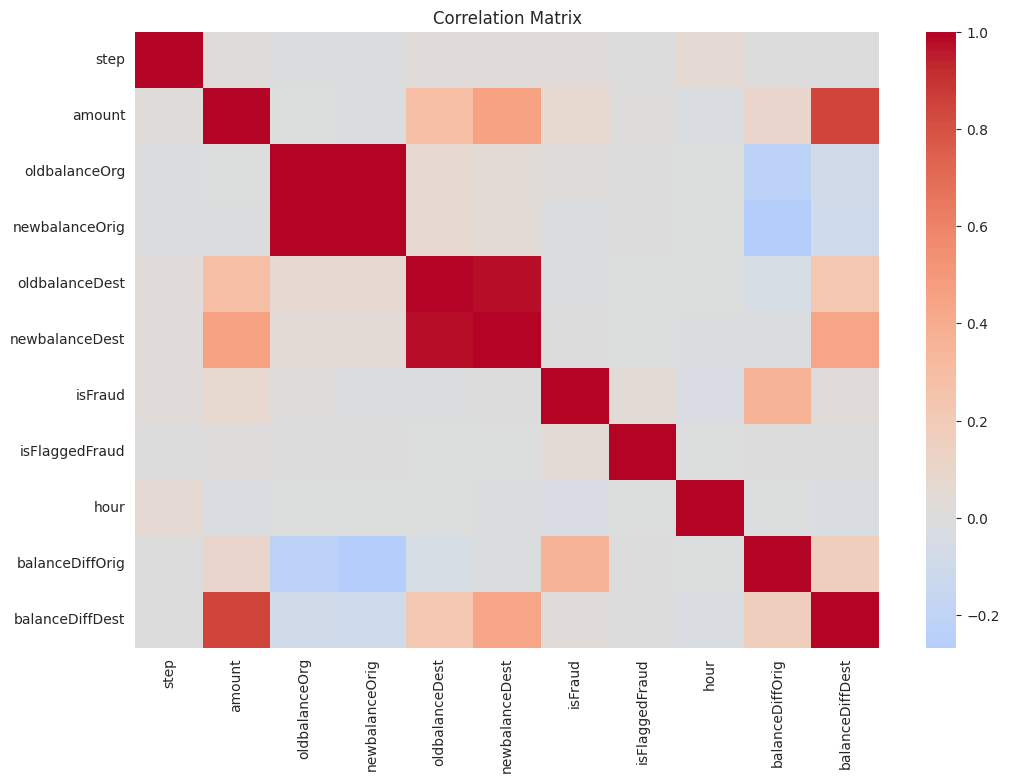

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

# Data Preprocessing

This stage prepares the dataset before machine learning modeling by handling irrelevant features, encoding categorical variables, and performing feature engineering.

Dropping Irrelevant Features

In [ ]:
df = df.drop(columns=[
    'nameOrig',
    'nameDest'
])

In [ ]:
df = df.drop(columns=['isFlaggedFraud'])

### Dropping Account ID Features

The account identifier columns were removed because they contain high-cardinality string values and are not directly suitable for baseline machine learning models.

Dataset Preview

In [ ]:
print(df.head())

   step      type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1   PAYMENT   9839.64       170136.0       160296.36             0.0   
1     1   PAYMENT   1864.28        21249.0        19384.72             0.0   
2     1  TRANSFER    181.00          181.0            0.00             0.0   
3     1  CASH_OUT    181.00          181.0            0.00         21182.0   
4     1   PAYMENT  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  hour  balanceDiffOrig  balanceDiffDest  
0             0.0        0     1          9839.64              0.0  
1             0.0        0     1          1864.28              0.0  
2             0.0        1     1           181.00              0.0  
3             0.0        1     1           181.00         -21182.0  
4             0.0        0     1         11668.14              0.0  


Encoding categorical

In [ ]:
encoder = LabelEncoder()

df['type'] = encoder.fit_transform(df['type'])

### Encoding Transaction Type

The transaction type feature was encoded into numerical values using Label Encoding so it can be processed by machine learning algorithms.

Mapping Encoding

In [ ]:
mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print(mapping)

{'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}


Dataset Preview

In [ ]:
print(df.head())

   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  hour  balanceDiffOrig  balanceDiffDest  
0             0.0        0     1          9839.64              0.0  
1             0.0        0     1          1864.28              0.0  
2             0.0        1     1           181.00              0.0  
3             0.0        1     1           181.00         -21182.0  
4             0.0        0     1         11668.14              0.0  


Data Type Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   type             int64  
 2   amount           float64
 3   oldbalanceOrg    float64
 4   newbalanceOrig   float64
 5   oldbalanceDest   float64
 6   newbalanceDest   float64
 7   isFraud          int64  
 8   hour             int64  
 9   balanceDiffOrig  float64
 10  balanceDiffDest  float64
dtypes: float64(7), int64(4)
memory usage: 534.0 MB


# Feature Engineering

Additional balance-related features were created to capture abnormal balance changes that may indicate fraudulent activity.

Feature Engineering

In [ ]:
df['balanceDiffOrig'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

In [ ]:
df['balanceDiffDest'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
)

In [ ]:
df['errorBalanceOrig'] = (
    df['newbalanceOrig'] + df['amount']
) - df['oldbalanceOrg']

In [ ]:

df['errorBalanceDest'] = (
    df['oldbalanceDest'] + df['amount']
) - df['newbalanceDest']

#Modeling data

# Machine Learning Modeling

Two machine learning models were used:
- Logistic Regression (baseline model)
- Random Forest (tree-based ensemble model)

#train test split


In [ ]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

Train-Test Split

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train-Test Distribution

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(5090096, 12)
(1272524, 12)
isFraud
0    5083526
1       6570
Name: count, dtype: int64
isFraud
0    1270881
1       1643
Name: count, dtype: int64


train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Model Logistic Regression

In [ ]:
class_weight='balanced'

In [ ]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

Model Training

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Model Prediction

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.953750184672352


Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.02      0.88      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.92      0.51   1272524
weighted avg       1.00      0.95      0.98   1272524



### Logistic Regression Analysis

The Logistic Regression model achieved high recall but extremely low precision for fraud detection.

This indicates that the model successfully captured most fraudulent transactions but generated many false positives.

Confusion Matrix

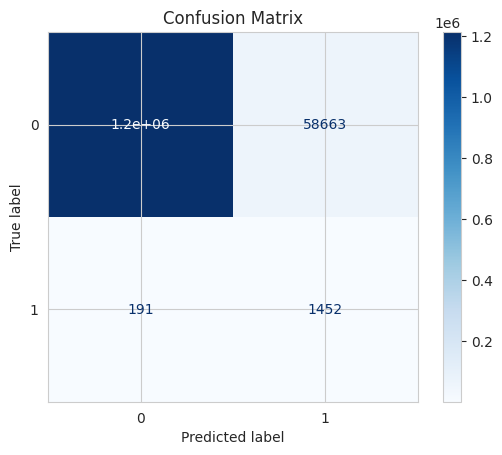

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix')

plt.show()

ROC-AUC Score

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9751711057180699


### ROC-AUC Interpretation

The ROC-AUC score indicates that the model has strong capability in distinguishing fraudulent and non-fraudulent transactions.

ROC Curve

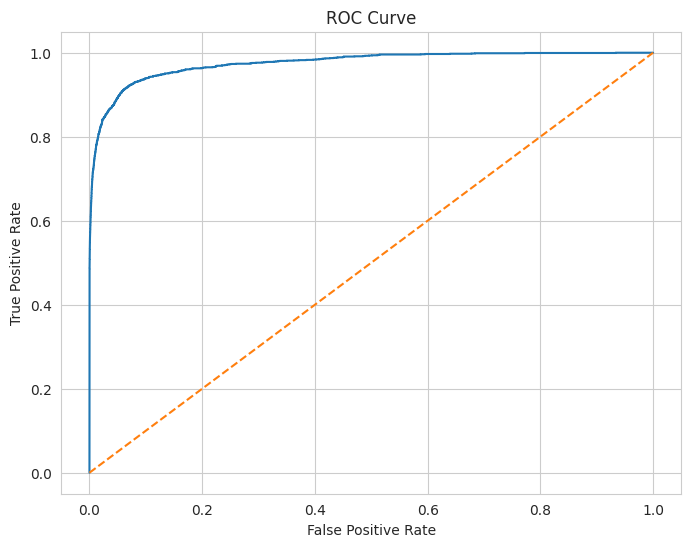

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

# Random Forest Classification

### Random Forest Analysis

Random Forest achieved near-perfect performance on the PaySim dataset.

This may be caused by highly separable fraud patterns within the synthetic dataset.

Handling Class Imbalance with Class Weight

In [ ]:
class_weight='balanced'

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

Model Training

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

Model Prediction

In [ ]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Accuracy

In [ ]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy:", accuracy_rf)

Accuracy: 0.9999968566408177


Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [ ]:
fraud_df = df[df['isFraud'] == 1]

print(
    fraud_df[
        ['oldbalanceDest', 'newbalanceDest']
    ].describe()
)

       oldbalanceDest  newbalanceDest
count    8.213000e+03    8.213000e+03
mean     5.442496e+05    1.279708e+06
std      3.336421e+06    3.908817e+06
min      0.000000e+00    0.000000e+00
25%      0.000000e+00    0.000000e+00
50%      0.000000e+00    4.676420e+03
75%      1.478287e+05    1.058725e+06
max      2.362305e+08    2.367265e+08


In [ ]:
print(
    (
        (fraud_df['oldbalanceDest'] == 0) &
        (fraud_df['newbalanceDest'] == 0)
    ).mean()
)

0.49628637525873615


# Dataset Limitation

The PaySim dataset is synthetic, meaning that some fraud patterns may be unrealistically separable compared to real-world banking fraud data.

This can lead to unusually high model performance, especially for powerful tree-based algorithms such as Random Forest.

Confusion Matrix

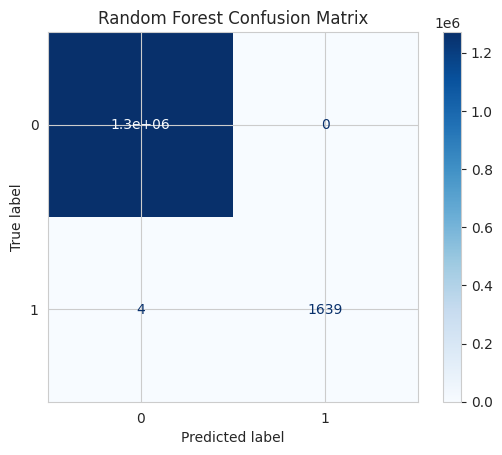

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp_rf.plot(cmap='Blues')

plt.title('Random Forest Confusion Matrix')

plt.show()

ROC-AUC Score

In [ ]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("ROC-AUC Score:", roc_auc_rf)

ROC-AUC Score: 0.9987819482841316


ROC Curve

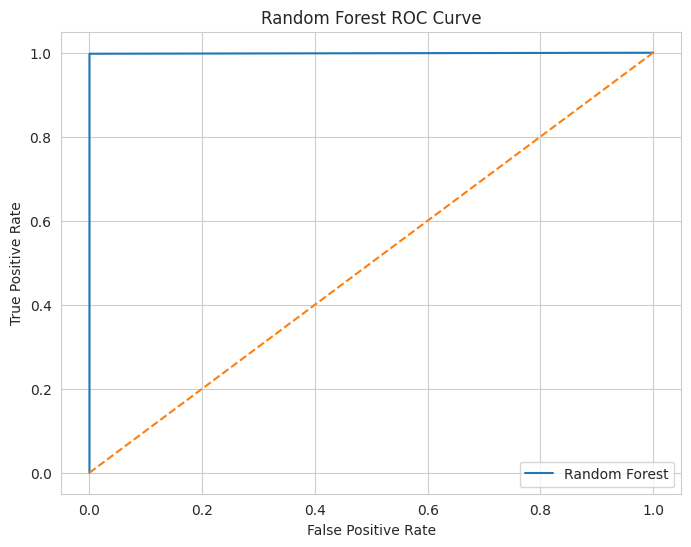

In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Random Forest ROC Curve')

plt.legend()

plt.show()

Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
10  errorBalanceOrig    0.306705
8    balanceDiffOrig    0.219578
4     newbalanceOrig    0.136006
3      oldbalanceOrg    0.081725
1               type    0.078234
2             amount    0.057368
11  errorBalanceDest    0.040520
9    balanceDiffDest    0.025215
0               step    0.021563
7               hour    0.016554
6     newbalanceDest    0.010963
5     oldbalanceDest    0.005568


Visualisasi Feature Importance

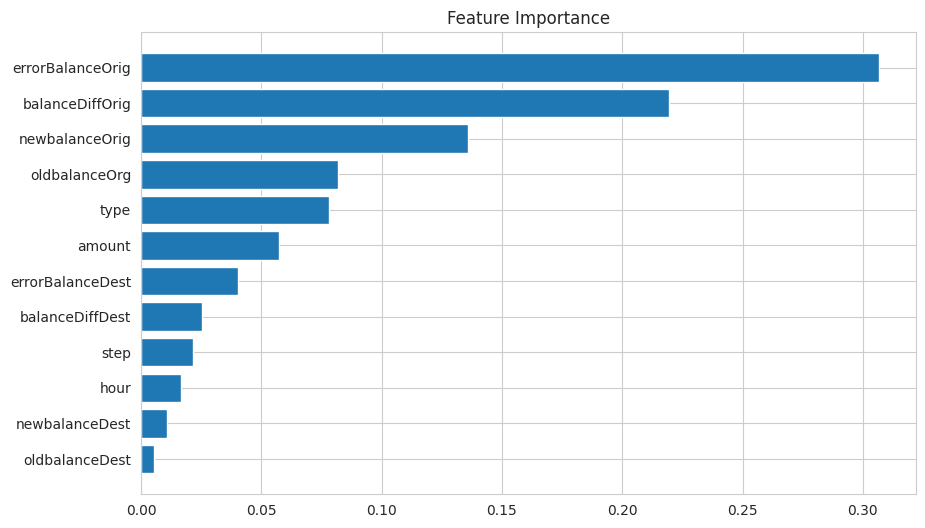

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance')

plt.gca().invert_yaxis()

plt.show()

# Conclusion

This project successfully analyzed fraudulent transaction patterns using the PaySim dataset and evaluated machine learning models for fraud detection.

Key findings:
- Fraud transactions are highly imbalanced
- Fraud mainly occurs in TRANSFER and CASH_OUT transaction types
- Logistic Regression achieved high recall but suffered from low precision due to excessive false positives
- Random Forest achieved near-perfect performance, likely caused by highly separable fraud patterns within the synthetic dataset

This project also highlights the limitations of synthetic datasets in representing real-world fraud detection scenarios.

Business Impact

TRANSFER and CASH_OUT transactions may require stricter fraud monitoring mechanisms due to their higher fraud occurrence rates.